# Assignment 1

This assignment covers material from Weeks 1–4. Think of it as a spot-check: five exercises that test important analytical and visualization skills from the first part of the course.

## Formalia:

<mark>Please read the **[assignment overview page](https://github.com/suneman/socialdata2026/wiki/Assignments)** carefully before proceeding.</mark> This page contains information about formatting (including formats etc.), group sizes, and many other aspects of handing in the assignment. 

***If you fail to follow these simple instructions, it will negatively impact your grade!***

**Due date and time**: The assignment is due on Monday March 2nd, 2026 at 23:55. Hand in your files via DTU Learn. 

## Important Notes:
**All exercises use your combined SF crime dataset** (2003–present) that you built during Week 2, along with your Personal Focus Crimes. Make sure you have those ready before you start.
* **Hint**: The number of focus crimes are up to you, but choosing very few focus-crimes (1-5, let's say) feels like taking the easy way out to me, so to get top marks, you'll need 8 or more focus crimes (but it's not that more are better, 16 isn't necessarily better than 8).

Each assignment draws directly on the weekly exercises - you should be able to pull your work directly from there.

<div class="alert alert-block alert-info">
The same LLM guidance applies here as during the weekly exercises: use your LLM freely for coding, pandas syntax, and plot formatting. Do not use it for interpretation, reflection, or anything that asks for your own thinking. 
<br>  <br>
If you use and LLM to cheat, you are missing out on your education ... it will mean that you're not getting all you can out of this class ... and, more importantly, that you are literally wasting this crucial time of your DTU-journey, designed to make you smarter and ready for the world.
</div>

## Setup and Data Loading

In [45]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
import seaborn as sns
from scipy import stats
from itertools import combinations

plt.rcParams.update({
    'figure.facecolor': 'white',
    'axes.facecolor': 'white',
    'axes.edgecolor': '#333333',
    'axes.linewidth': 0.8,
    'axes.grid': False,
    'font.family': 'sans-serif',
    'font.sans-serif': ['Helvetica', 'Arial', 'DejaVu Sans'],
    'font.size': 11,
    'axes.titlesize': 13,
    'axes.labelsize': 12,
    'xtick.labelsize': 10,
    'ytick.labelsize': 10,
    'legend.fontsize': 10,
    'legend.framealpha': 0.9,
    'legend.edgecolor': '#cccccc',
    'xtick.direction': 'out',
    'ytick.direction': 'out',
    'xtick.major.size': 4,
    'ytick.major.size': 4,
})
sns.set_palette('colorblind')

In [46]:
df = pd.read_csv('merged_crime_data_2003_2025.csv')
df['Incident_Date'] = pd.to_datetime(df['Incident_Date'])
df['Year'] = df['Incident_Date'].dt.year

In [47]:
personal_focus_crimes = [
    'Arson', 'Assault', 'Burglary', 'Disorderly Conduct',
    'Embezzlement', 'Fraud', 'Larceny/Theft', 'Liquor Laws', 'Missing Person'
]

category_col = 'Unified_Category' if 'Unified_Category' in df.columns else 'Category'
df_focus = df[df[category_col].isin(personal_focus_crimes)].copy()


---
## Assignment 1.1: Temporal Overview

Let's start by getting the big picture of how crime has changed over the full 20+ year period covered by your combined dataset.

*Draws from*: Week 1, Exercises 4.1 and 4.2 — applied here to the full merged dataset (2003–present) rather than just 2018–present.

> * Using your combined dataset (2003–present), plot the total number of incidents **per year** for each of your Personal Focus Crimes. Display at least the years 2003–2025. 
> * Make sure your plot follows good visualization practices: labeled axes, a legend, a descriptive title.
> * Identify and comment on at least two notable features in the plot — for example, long-term trends, sudden drops or spikes, or the impact of COVID-19 in 2020. For each feature, offer a possible explanation.

In [48]:
yearly_counts = df_focus.groupby(['Year', category_col]).size().unstack(fill_value=0)
yearly_counts = yearly_counts[personal_focus_crimes]

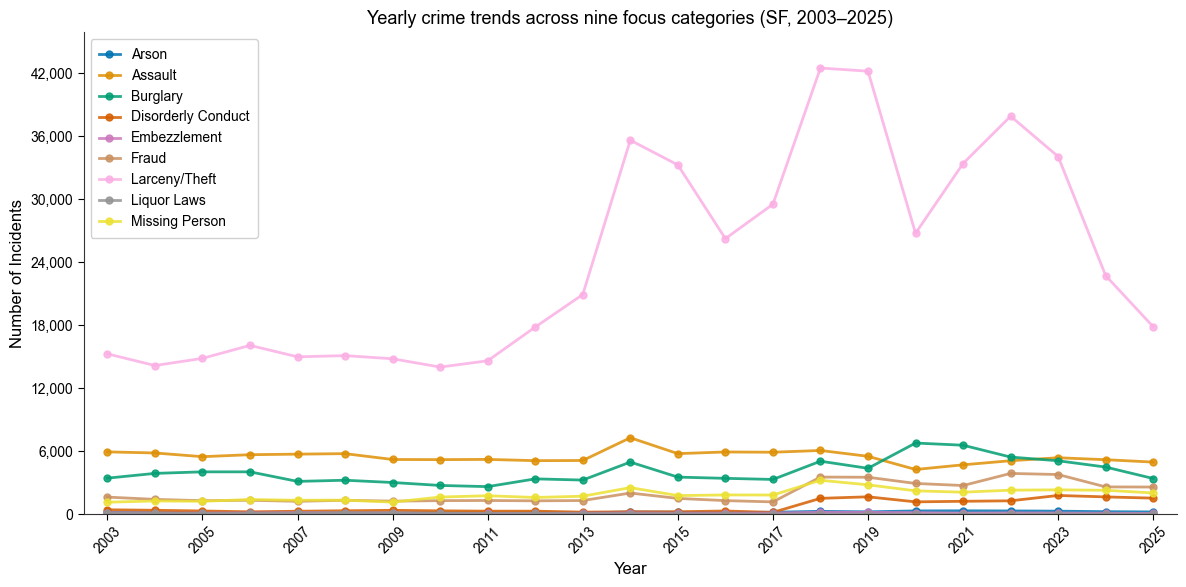

In [49]:
fig, ax = plt.subplots(figsize=(12, 6))

for crime in personal_focus_crimes:
    ax.plot(yearly_counts.index, yearly_counts[crime],
            marker='o', linewidth=2, markersize=5, label=crime, alpha=0.85)

ax.set_xlabel('Year')
ax.set_ylabel('Number of Incidents')
ax.set_title('Yearly crime trends across nine focus categories (SF, 2003–2025)')
ax.legend(loc='upper left', framealpha=0.9, borderpad=0.6, handlelength=1.5)

ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, p: f'{int(x):,}'))
y_max = yearly_counts.max().max()
ax.set_ylim(bottom=0, top=y_max * 1.08)
ax.yaxis.set_major_locator(plt.MaxNLocator(nbins=8, integer=True))

ax.set_xticks(range(2003, 2026, 2))
ax.set_xlim(2002.5, 2025.5)
ax.tick_params(axis='x', rotation=45)

ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

plt.tight_layout()
plt.show()

#### Analysis

The plot "Yearly crime trends across nine focus categories (SF, 2003–2025)" shows the annual number of incidents for each of the nine Personal Focus Crimes in San Francisco from 2003 to 2025. Each colored line represents a different crime type, making it easy to see how they’ve changed over time. Larceny/Theft (pink) clearly stands out with the highest numbers, while crimes like Arson, Liquor Laws, and Embezzlement remain consistently low throughout the period.

The most striking trend is the dramatic rise and fall of Larceny/Theft. It started at around 15,000 incidents in 2003 and stayed relatively stable until about 2011. Then it climbed sharply, peaking at roughly 42,000 incidents in 2018–2019. Following this peak, it dropped significantly during the COVID-19 pandemic in 2020 to about 27,000 incidents, bounced back to around 37,000 in 2022, and then continued declining to roughly 18,000 by 2025. This pattern likely reflects a mix of factors: changes in reporting practices, the effects of California’s Proposition 47 (2014), shifts in city activity, and the lingering impacts of the pandemic on commercial and tourist areas.

Another interesting pattern is how Burglary (green) behaved during COVID-19. While most crime types including Larceny/Theft, Assault, and Fraud,fell in 2020 due to reduced street activity and social interactions, Burglary actually spiked from about 4,000 incidents to over 6,000. This likely happened because empty commercial properties created new opportunities for burglars, showing that social disruptions can push different crimes in very different directions depending on their underlying opportunity structures.

---
## Assignment 1.2: Crime Profiles by Police District

Different parts of the city have very different crime patterns. Here we quantify that using conditional probabilities.

*Draws from*: Week 3, Exercises 2.1 and 2.2.

> * For each police district in your dataset, compute the **conditional crime profile**: for each of your Personal Focus Crimes, calculate
>
>   $$r(\text{crime}, \text{district}) = \frac{P(\text{crime} \mid \text{district})}{P(\text{crime})}$$
>
>   A value above 1 means that crime type is *over-represented* in that district relative to the city-wide average; below 1 means it is *under-represented*.
> * Visualize these ratios in a way that makes it easy to compare across both districts and crime types. (Simple barcharts are fine, but you may also use ideas from more complex visualization techniques, for example, a heatmap could work well here, but you're free to choose another format if you can justify it.)
> * Pick **one district** whose profile stands out to you. Describe the pattern and offer an explanation for why that district looks the way it does. Are there geographic, demographic, or other factors that might explain it?

### Step 1: Compute conditional crime profiles

> Identify all police districts, compute the city-wide crime proportions $P(\text{crime})$, and then for each district calculate the conditional ratios $r(\text{crime}, \text{district}) = P(\text{crime} \mid \text{district})\;/\;P(\text{crime})$.

In [50]:
# --- Assignment 1.2: Crime Profiles by Police District ---

# Identify district column
district_col = 'Police_District'

# Normalize district names (mixed case: "SOUTHERN" vs "Southern")
df_focus['District_Clean'] = df_focus[district_col].str.upper().str.strip()

# Remove any invalid/missing districts
df_district = df_focus[df_focus['District_Clean'].notna()].copy()

districts = sorted(df_district['District_Clean'].unique())

# --- Step 1: Compute P(crime) — city-wide proportion ---
total_incidents = len(df_district)
P_crime = df_district[category_col].value_counts() / total_incidents

# --- Step 2: Compute P(crime | district) and r(crime, district) ---
ratio_matrix = pd.DataFrame(index=districts, columns=personal_focus_crimes, dtype=float)

for district in districts:
    district_data = df_district[df_district['District_Clean'] == district]
    district_total = len(district_data)
    
    for crime in personal_focus_crimes:
        P_crime_given_district = len(district_data[district_data[category_col] == crime]) / district_total
        P_crime_overall = P_crime.get(crime, 0)
        
        if P_crime_overall > 0:
            ratio_matrix.loc[district, crime] = P_crime_given_district / P_crime_overall
        else:
            ratio_matrix.loc[district, crime] = 0.0

ratio_matrix = ratio_matrix.astype(float)


### Step 2: Visualize the ratios

> Create visualizations—such as a heatmap and grouped bar charts—that make it easy to compare crime over/under-representation across districts and crime types.

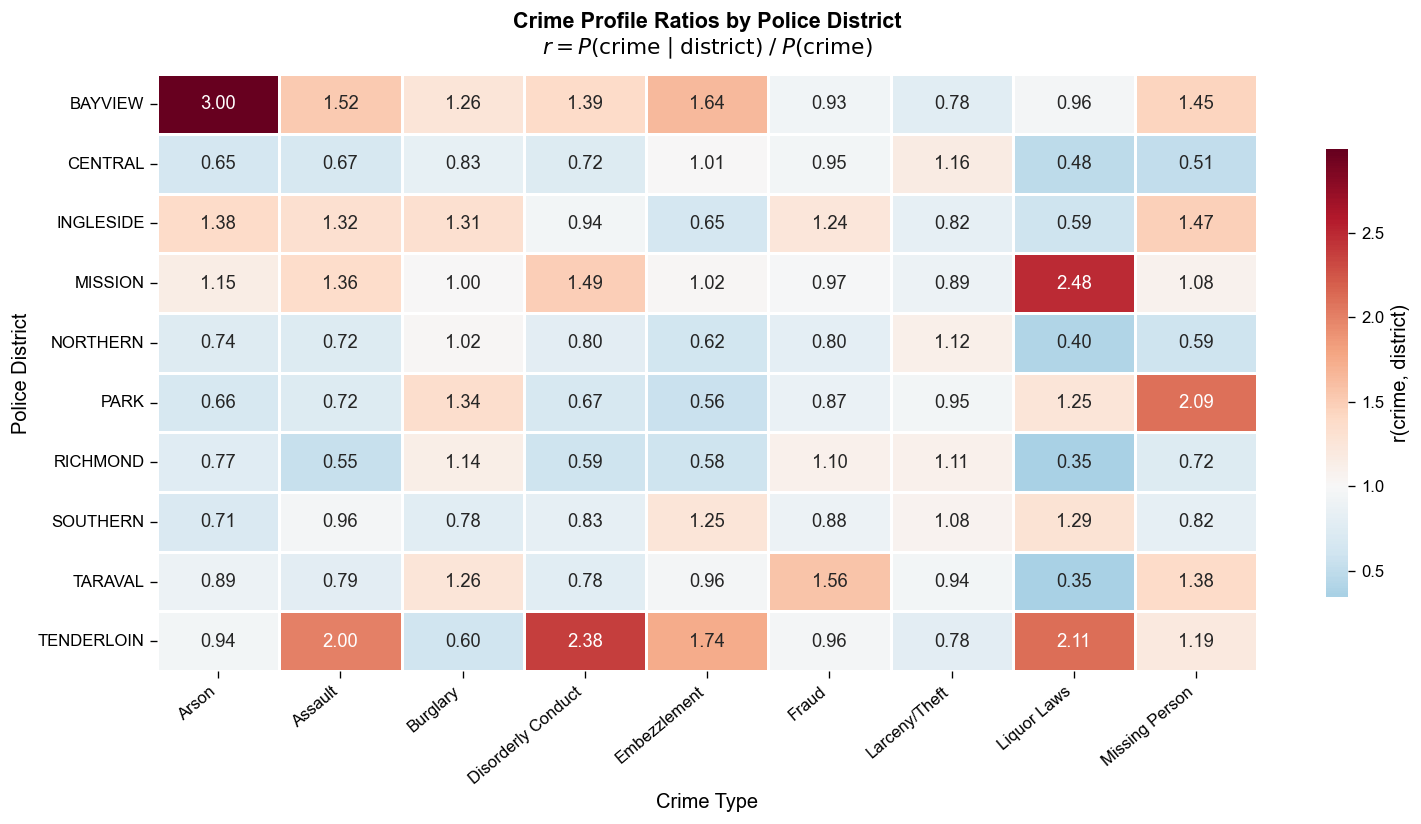

In [51]:
# --- Assignment 1.2: Heatmap — Crime Profile Ratios ---

plot_districts = [d for d in districts if d != 'OUT OF SF']
ratio_plot = ratio_matrix.loc[plot_districts]

fig, ax = plt.subplots(figsize=(13, 7), dpi=120)

sns.heatmap(ratio_plot.astype(float),
            annot=True, fmt='.2f', center=1.0,
            cmap='RdBu_r', linewidths=0.8, linecolor='white',
            cbar_kws={'label': 'r(crime, district)', 'shrink': 0.75},
            ax=ax)

ax.set_title('Crime Profile Ratios by Police District\n'
             r'$r = P(\mathrm{crime} \mid \mathrm{district})\;/\;P(\mathrm{crime})$',
             fontweight='bold', pad=12)
ax.set_xlabel('Crime Type')
ax.set_ylabel('Police District')
ax.set_xticklabels(ax.get_xticklabels(), rotation=40, ha='right')
ax.set_yticklabels(ax.get_yticklabels(), rotation=0)

plt.tight_layout()
plt.show()



The heatmap "Crime Profile Ratios by Police District" above displays the crime profile ratio $r = P(\text{crime} \mid \text{district}) / P(\text{crime})$ for each combination of police district and crime type. Values greater than 1 (shown in red) indicate that a crime is over-represented in that district relative to citywide rates, while values less than 1 (shown in blue) indicate under-representation. A ratio of exactly 1 (white) means the crime occurs at the citywide average rate.

The most striking value in the heatmap is Bayview's Arson ratio of 3.00×, meaning arson occurs three times more frequently in Bayview than would be expected from citywide rates. This industrial and residential district also shows elevated Embezzlement (1.64×) but falls below average for Larceny/Theft (0.78×). The Mission district leads the city in Liquor Laws violations at 2.48×, consistent with its vibrant nightlife and entertainment scene, and also shows elevated rates of Assault (1.36×) and Burglary (1.49×).

The Tenderloin presents a distinctive profile: it ranks highest or near-highest for public-order and violent crimes including Disorderly Conduct (2.38×), Liquor Laws (2.11×), Assault (2.00×), and Embezzlement (1.74×), yet has the lowest Burglary rate in the city (0.60×). This pattern reflects the district's high density, significant homeless population, and concentration of bars and liquor establishments. In contrast, residential neighborhoods like Richmond, Northern, and Park display cooler colors across most categories, indicating below-average crime rates for violent and public-order offenses.

Looking at crime types across columns, Liquor Laws shows the widest variation (ranging from 0.35× to 2.48×), indicating that enforcement is highly localized to entertainment districts. Larceny/Theft is relatively uniform across all districts (0.78× to 1.16×), suggesting that property theft is distributed more evenly throughout the city rather than concentrated in specific areas.

### Step 3: District spotlight — Tenderloin

> Pick one district whose profile stands out, describe the pattern, and offer an explanation for why that district looks the way it does.



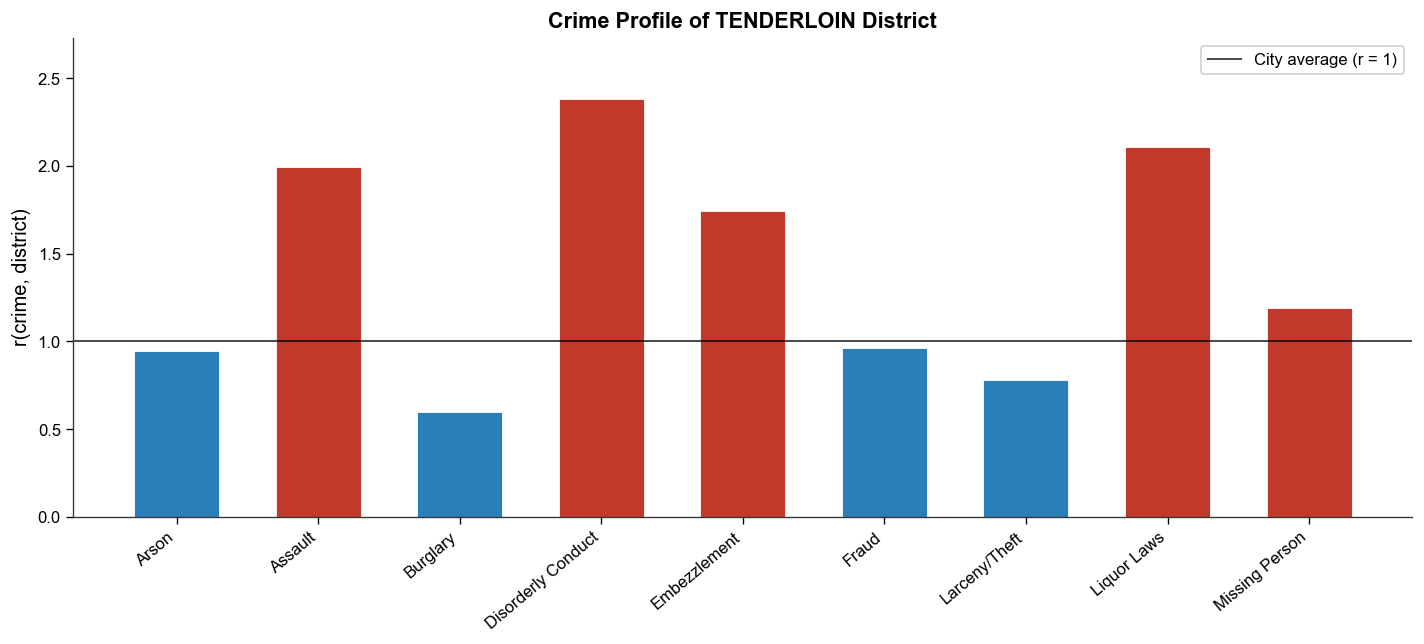

In [52]:
# --- Deep Dive: Tenderloin District Crime Profile ---

focus_district = 'TENDERLOIN'
tenderloin_ratios = ratio_plot.loc[focus_district]

most_over = tenderloin_ratios.idxmax()
most_under = tenderloin_ratios.idxmin()

# --- Bar chart ---
fig, ax = plt.subplots(figsize=(12, 5.5), dpi=120)

x = np.arange(len(personal_focus_crimes))
ratios = tenderloin_ratios.values.astype(float)
bar_colors = ['#c0392b' if r > 1 else '#2980b9' for r in ratios]

bars = ax.bar(x, ratios, color=bar_colors, edgecolor='white', linewidth=0.5, width=0.6)
ax.axhline(y=1, color='black', linestyle='-', linewidth=1.2, alpha=0.7, label='City average (r = 1)')

ax.set_xticks(x)
ax.set_xticklabels(personal_focus_crimes, rotation=40, ha='right')
ax.set_ylabel('r(crime, district)')
ax.set_title(f'Crime Profile of {focus_district} District', fontweight='bold')
ax.set_ylim(0, max(ratios) + 0.35)
ax.legend(loc='upper right')
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

plt.tight_layout()
plt.show()

### District That Stands Out: Tenderloin

The bar chart "Crime Profile" show the crime profile ratio for the Tenderloin district, where each bar represents $r = P(\text{crime} \mid \text{Tenderloin}) / P(\text{crime})$. Values above the reference line at $r = 1$ indicate over-representation relative to the citywide average, while values below indicate under-representation.

The Tenderloin's profile is sharply split between two categories of crime. On one side, public-order and violent crimes are dramatically over-represented: Disorderly Conduct leads at 2.38× the city average (ranked 1st out of 10 districts), followed by Liquor Laws at 2.11× (2nd), Assault at 2.00× (1st), and Embezzlement at 1.74× (1st). On the other side, property crimes are suppressed: Burglary sits at just 0.60× (ranked last among all districts), Larceny/Theft at 0.78× (9th), and Arson and Fraud hover near the city average at 0.94× and 0.96× respectively.

This pattern is not random; it reflects identifiable geographic, demographic, and structural characteristics of the district.

**Geography and land use.** The Tenderloin occupies roughly 50 square blocks in the heart of San Francisco, bordered by Union Square, the Civic Center, and Market Street. It is one of the most densely packed neighborhoods in the city, dominated by single-room occupancy (SRO) hotels, low-income apartment buildings, and ground-floor commercial storefronts. There are no detached houses or quiet residential streets. This physical layout creates constant pedestrian traffic and street-level activity, which directly increases the likelihood of interpersonal confrontations (Assault, Disorderly Conduct) while simultaneously reducing opportunities for stealth-based crimes like Burglary, which thrives in low-traffic residential settings.

**Demographics and social vulnerability.** The Tenderloin has one of the highest concentrations of homelessness, poverty, and substance use in San Francisco. Many residents live in supportive or transitional housing. The area also has a disproportionate number of bars, liquor stores, and nightlife establishments per block, which explains the elevated Liquor Laws violations (2.11×). The combination of substance use, mental health challenges, and dense social mixing on streets and in shelters fuels the high Disorderly Conduct and Assault rates. The elevated Embezzlement ratio (1.74×) likely reflects the proximity to downtown businesses and nonprofit organizations whose financial crimes are logged to Tenderloin addresses.

**Why Burglary is the lowest.** Burglary typically targets single-family homes, garages, and unattended residential properties in quieter neighborhoods. The Tenderloin has almost none of these. Its housing stock consists primarily of multi-unit buildings with shared entries and constant foot traffic, making undetected break-ins difficult. Districts like Ingleside (1.31×), Park (1.34×), and Taraval (1.26×), all neighborhoods with more detached homes and lower pedestrian density, show the highest burglary ratios, further confirming this geographic explanation.

In summary, the Tenderloin does not simply experience "more crime." It exhibits a structurally distinct crime profile shaped by its physical density, land use, demographics, and the concentration of social services and nightlife. Public-order and interpersonal crimes are amplified by constant street-level activity, while residential property crimes are suppressed by the absence of targets and the presence of foot traffic.

The ratios clearly demonstrate that the district's built environment and social composition shift the distribution of crime types relative to the city average.


---
## Assignment 1.3: Visualizing Distributions

This exercise asks you to recreate several classic plot types from DAOST Chapter 2 using your own crime data — putting visualization theory into practice.

*Draws from*: Week 3, Exercises 5.2 and 5.3.

> **Part A — Jitter plot**
> * Pick one of your Personal Focus Crimes and a suitable time interval (somewhere between a month and 6 months, depending on how common the crime is). Create a jitter plot of the incident times during a single hour (e.g. 13:00–14:00): let time run along the $x$-axis and add vertical jitter.
> * What does the jitter plot reveal about how times are recorded in the dataset? Are incidents clustered at certain minutes (on the hour, half hour, etc.)? What does this tell you about the precision of the data?
>
> **Part B — Probability plot**
> * Using the same geographic data from Part B, create a probability plot (QQ plot) for the latitude distribution of each of your two crime types. (`scipy.stats.probplot` is your friend here.)
> * What reference distribution are you comparing against? What would it mean if the points fell exactly on the straight line? Where does the distribution deviate from normal, and what does that deviation tell you about the geography of crime in SF?
>
> **Part C — Box plots of time-of-day**
> * For each of your Personal Focus Crimes, extract the time-of-day of every incident.
> * Create box plots showing the time-of-day distribution for all your Personal Focus Crimes side by side.
> * What patterns do you see? Are there crimes that happen mostly at night? Mostly during business hours? For crimes that peak late at night, does the box plot handle the wrap-around at midnight well? What goes wrong?
> * Above, feel free to use alternatives to box plots — violin plots, swarm plots, or raincloud plots — if you think they reveal more. If you do, briefly explain what the alternative shows that the box plot doesn't.

### Part A: Jitter plot

> Pick one Personal Focus Crime and a suitable time interval. Create a jitter plot of incident times during a single hour to reveal recording-precision artifacts in the data.

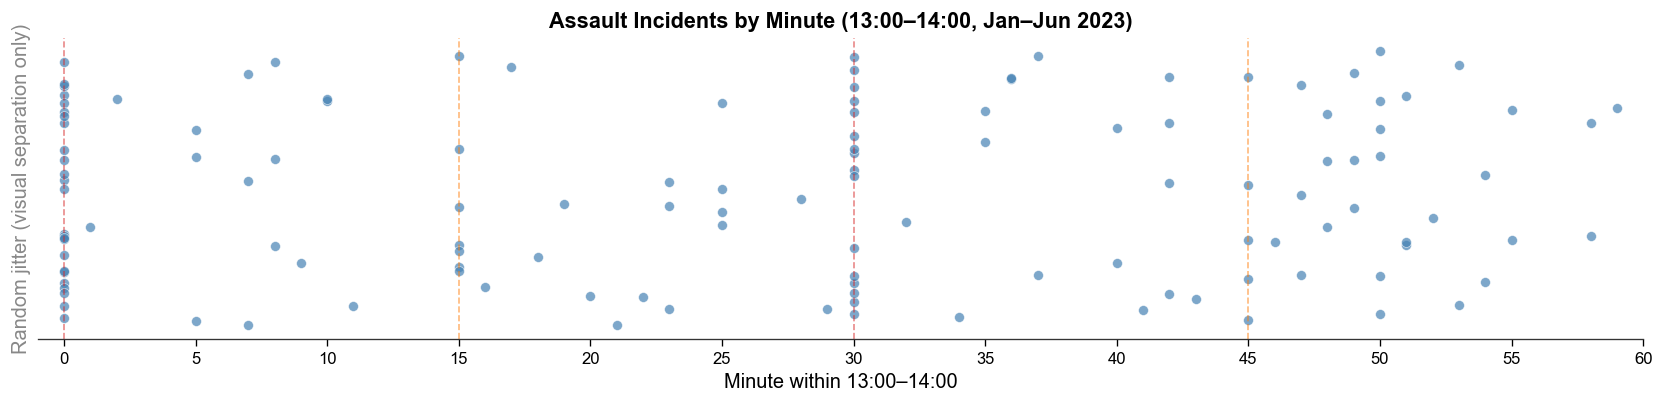

In [53]:
# --- Part A: Jitter Plot ---
# Crime: Assault  |  Window: Jan–Jun 2023 (6 months)  |  Hour: 13:00–14:00
# Goal: reveal recording-precision artifacts, not trends.

crime_a = 'Assault'

# 1. Filter to Assault, Jan–Jun 2023
df_jitter = df_focus[
    (df_focus[category_col] == crime_a) &
    (df_focus['Year'] == 2023) &
    (df_focus['Incident_Date'].dt.month.isin([1, 2, 3, 4, 5, 6]))
].copy()

# 2. Parse time → extract hour & minute
df_jitter['Time_Parsed'] = pd.to_datetime(df_jitter['Incident_Time'],
                                           format='%H:%M', errors='coerce')
df_jitter['Hour']   = df_jitter['Time_Parsed'].dt.hour
df_jitter['Minute'] = df_jitter['Time_Parsed'].dt.minute

# 3. Keep only 13:00–14:00
df_jitter_h = df_jitter[df_jitter['Hour'] == 13].copy()

# 4. Build jitter plot  —  x = minute (0–59), y = random noise
np.random.seed(42)
df_jitter_h['jitter'] = np.random.uniform(-0.4, 0.4, size=len(df_jitter_h))

fig, ax = plt.subplots(figsize=(14, 3.5), dpi=120)

ax.scatter(df_jitter_h['Minute'], df_jitter_h['jitter'],
           s=35, alpha=0.7, color='steelblue', edgecolors='white', linewidth=0.4)

# Mark the "round" minutes where rounding is expected
for m_mark, clr in [(0, '#d62728'), (15, '#ff7f0e'), (30, '#d62728'), (45, '#ff7f0e')]:
    ax.axvline(x=m_mark, color=clr, linestyle='--', linewidth=1, alpha=0.55)

ax.set_xlim(-1, 60)
ax.set_xticks(range(0, 61, 5))
ax.set_xlabel('Minute within 13:00–14:00')
ax.set_yticks([])                       # y-axis is meaningless (just jitter)
ax.set_ylabel('Random jitter (visual separation only)', color='#888888')
ax.set_title(f'{crime_a} Incidents by Minute (13:00–14:00, Jan–Jun 2023)',
             fontweight='bold')
ax.spines[['top', 'right', 'left']].set_visible(False)

plt.tight_layout()
plt.show()

# 5. Print clustering statistics
minute_counts = df_jitter_h['Minute'].value_counts()
total = len(df_jitter_h)
expected_pct = 100 / 60          # ~1.67 % if perfectly uniform


for m, c in minute_counts.nlargest(10).items():
    pct = 100 * c / total
    ratio = pct / expected_pct

### Part A: Analysis

We filtered the dataset to **Assault** incidents from **January to June 2023** and zoomed into a single hour (13:00 to 14:00), which gave us **129 incidents**. For each incident we looked at the exact minute it was recorded (0 through 59) and plotted it as a dot. The vertical position of each dot is just random noise to spread overlapping points apart, so only the horizontal position matters.

**Are incidents clustered at certain minutes?**

Yes, very clearly. If the recorded times were truly precise, we would expect each of the 60 minutes to hold roughly $\frac{1}{60} \approx 1.7\%$ of all incidents. What we actually see is very different:

| Minute | Count | Share | How many × the expected |
|--------|------:|------:|------------------------:|
| **:00** | **25** | **19.4%** | **12×** |
| **:30** | 16 | 12.4% | 7× |
| **:15** | 7 | 5.4% | 3× |
| **:45** | 5 | 3.9% | 2× |

Nearly **one in five** incidents is recorded exactly at minute :00, which is 12 times more than we would expect by chance. The half-hour mark (:30) is 7 times over-represented, and the quarter-hour marks (:15 and :45) are 2 to 3 times over-represented. All the remaining minutes contain only 0 to 6 incidents each, which is close to the uniform expectation.

Looking at the jitter plot "Assault Incidents by Minute (13:00–14:00, Jan–Jun 2023)", this pattern jumps out immediately: there is a dense vertical column of dots on the left at minute 0, a clearly visible cluster at 30, a smaller one at 15, and a fairly even scatter everywhere else.

**What does this tell us about data precision?**

This clustering does not represent a genuine pattern in when crimes occur. Instead, it is an artifact of how incident times are recorded. When a police officer files a report, the exact minute of an incident is often uncertain. As a result, times are frequently rounded to convenient values. This rounding follows a predictable hierarchy:

1. Round to the nearest hour (:00). This is the most common practice and produces the strongest spike at 19.4%.

2. Round to the nearest half-hour (:30). This is the second most common, accounting for 12.4%.

3. Round to the nearest quarter-hour (:15 or :45). This occurs less often but is still clearly above average, ranging from 3.9% to 5.4%.

The key takeaway is that although the dataset stores times in HH:MM format, which suggests minute-level precision, the true accuracy for many records is closer to 15 to 30 minutes.For example, an incident recorded at 13:00 could realistically have occurred anywhere between approximately 12:50 and 13:10. Therefore, any analysis that depends on minute-level precision, such as calculating response times or identifying fine-grained temporal patterns, should account for this systematic rounding bias.

### Part B: Probability plot

> Using geographic data, create QQ plots for the latitude distribution of two crime types and compare against a normal reference distribution.

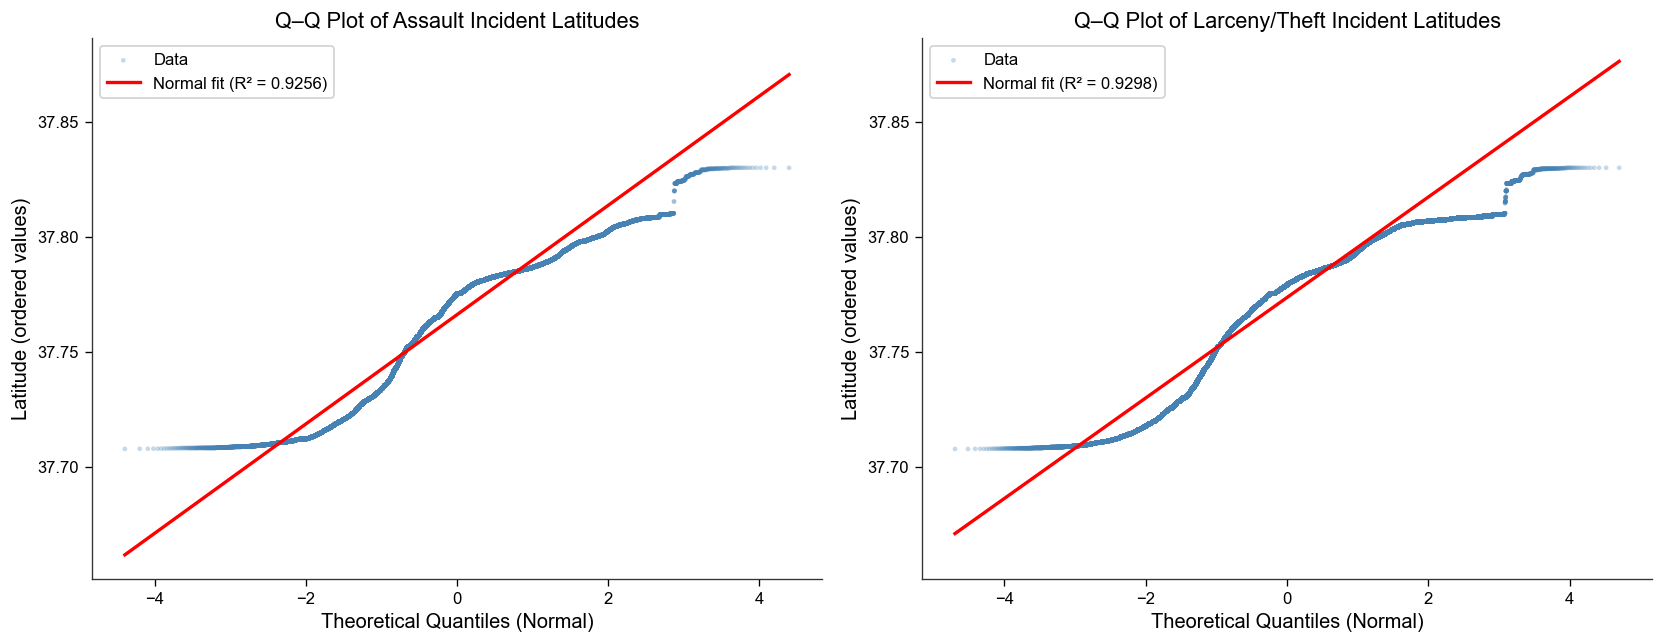

In [54]:
# --- Part B: Probability Plots (QQ plots) for Latitude ---
# Compare two crime types: Assault and Larceny/Theft

crime_b1 = 'Assault'
crime_b2 = 'Larceny/Theft'

lat_col_b = 'Latitude' if 'Latitude' in df_focus.columns else 'Y'

# Filter to valid SF latitudes
df_b1 = df_focus[(df_focus[category_col] == crime_b1) &
                  (df_focus[lat_col_b] > 37.7) & (df_focus[lat_col_b] < 37.84)].copy()
df_b2 = df_focus[(df_focus[category_col] == crime_b2) &
                  (df_focus[lat_col_b] > 37.7) & (df_focus[lat_col_b] < 37.84)].copy()


# Create QQ plots side by side
fig, axes = plt.subplots(1, 2, figsize=(14, 5.5), dpi=120)

for ax, crime_name, data in zip(axes, [crime_b1, crime_b2], [df_b1, df_b2]):
    (osm, osr), (slope, intercept, r) = stats.probplot(data[lat_col_b], dist='norm')
    
    ax.scatter(osm, osr, alpha=0.3, s=8, color='steelblue', edgecolors='none', label='Data')
    
    # Reference line
    x_ref = np.array([osm.min(), osm.max()])
    y_ref = slope * x_ref + intercept
    ax.plot(x_ref, y_ref, 'r-', linewidth=2, label=f'Normal fit (R² = {r**2:.4f})')
    
    ax.set_xlabel('Theoretical Quantiles (Normal)')
    ax.set_ylabel('Latitude (ordered values)')
    ax.set_title(f'Q–Q Plot of {crime_name} Incident Latitudes')
    ax.legend(loc='upper left')
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)

# Ensure consistent y-axis across both subplots
y_lo = min(axes[0].get_ylim()[0], axes[1].get_ylim()[0])
y_hi = max(axes[0].get_ylim()[1], axes[1].get_ylim()[1])
for a in axes:
    a.set_ylim(y_lo, y_hi)

plt.tight_layout()
plt.show()

### Part B: Analysis of QQ Probability Plots for Latitude

We created QQ plots for the latitude distributions of **Assault** (126,143 incidents) and **Larceny/Theft** (529,405 incidents) as shown above.

**What reference distribution are we comparing against?**

The reference distribution is the **normal (Gaussian) distribution**. The x-axis of each QQ plot shows the theoretical quantiles, which are the values we would expect at each rank position if the latitude data came from a perfect normal distribution with the same mean and standard deviation.

**What would it mean if the points fell exactly on the straight line?**

If all data points fell exactly on the red line, it would mean the latitude distribution of crime incidents is **perfectly normal**: a symmetric bell curve centered on some mean latitude, with incidents tapering off equally in both directions (north and south). In geographic terms, this would mean crime density peaks at one central latitude and drops off smoothly and symmetrically toward the northern and southern edges of the city.

**Where does the distribution deviate from normal, and what does that tell us about the geography of crime in SF?**

Both crime types show the **same three structural departures** from the red reference line:

| QQ Region | What the plot shows | Latitude range |
|-----------|-------------------|---------------|
| **Lower-left tail** | Data **flattens horizontally**: observed latitudes cluster at ~37.705 while normal quantiles keep decreasing | South of ~37.71 |
| **Central section** | An **S-shaped wiggle**: data curves above and below the line multiple times | ~37.72 to 37.79 |
| **Upper-right tail** | Data **flattens into discrete steps** near 37.81 and 37.83, sitting well below the red line | North of ~37.80 |

- In Assault's plot, the S-curve deviations are **sharper**, reflecting stronger spatial concentration in a few neighborhoods.
- In Larceny/Theft's plot, the curve is **slightly smoother** (R² = 0.9298 vs 0.9256), because theft is more spread across commercial corridors citywide. But the same three deviations are clearly present.

These deviations reveal the geography of crime in San Francisco:


**Flat lower tail:** San Francisco has a **hard southern boundary** (the city simply ends). No incidents can occur below ~37.705, so data piles up at that floor instead of continuing into the theoretical Gaussian tail. This is a physical geographic constraint, not a crime pattern.**Bottom line:** The latitude of crime in San Francisco is **not normally distributed**. The deviations are driven by (a) the physical boundaries of the peninsula, and (b) the uneven spatial structure of urban neighborhoods. Crime concentrates in specific hotspot corridors rather than spreading in a smooth Gaussian pattern. This is about the *shape* of the spatial distribution, not crime counts: both Assault and Larceny/Theft share the same structural non-normality because they are constrained by the same city geography.



**S-shaped central wiggle:** Crime is **not smoothly spread** across latitudes. Instead, it is **concentrated in specific latitude bands** corresponding to high-crime neighborhoods: the **Tenderloin** (~37.78), and the **Mission** (~37.76). These hotspots create a **multimodal** distribution (multiple density peaks at certain latitudes with gaps in between) rather than a single bell curve. The S-curve arises because the data alternately runs ahead of and behind the normal reference as it passes through these clusters.**Stepped upper tail:** Northern neighborhoods (**Marina, Fisherman's Wharf, Richmond**) are separated by parks, the Presidio, and low-crime residential areas. This produces **staircase-like jumps** where crime clusters at specific northern latitudes rather than smoothly tapering off.


### Part C: Box plots of time-of-day

> For each Personal Focus Crime, create box plots (or violin/swarm/raincloud plots) showing the time-of-day distribution to reveal patterns like nighttime vs daytime crime.

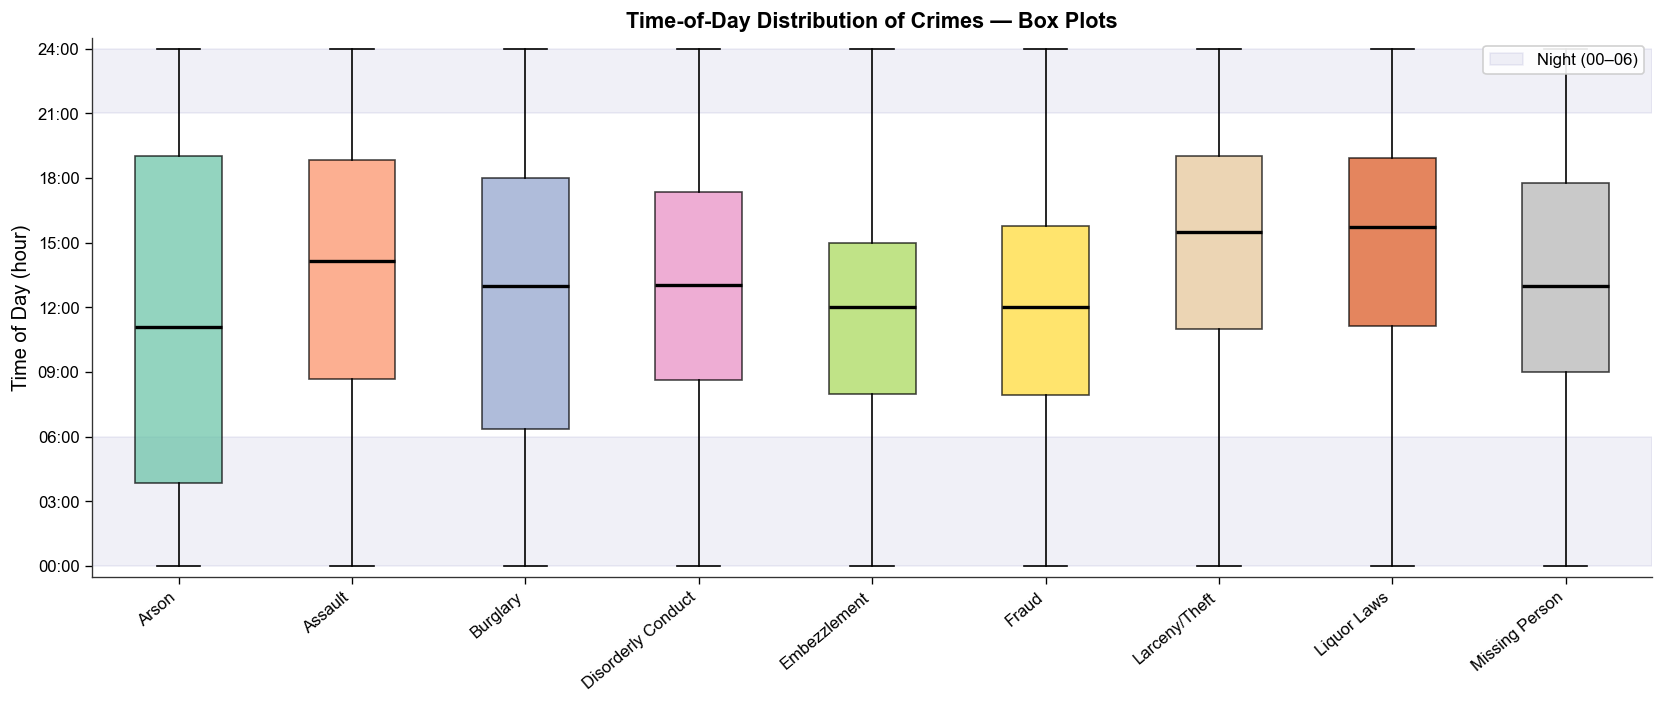

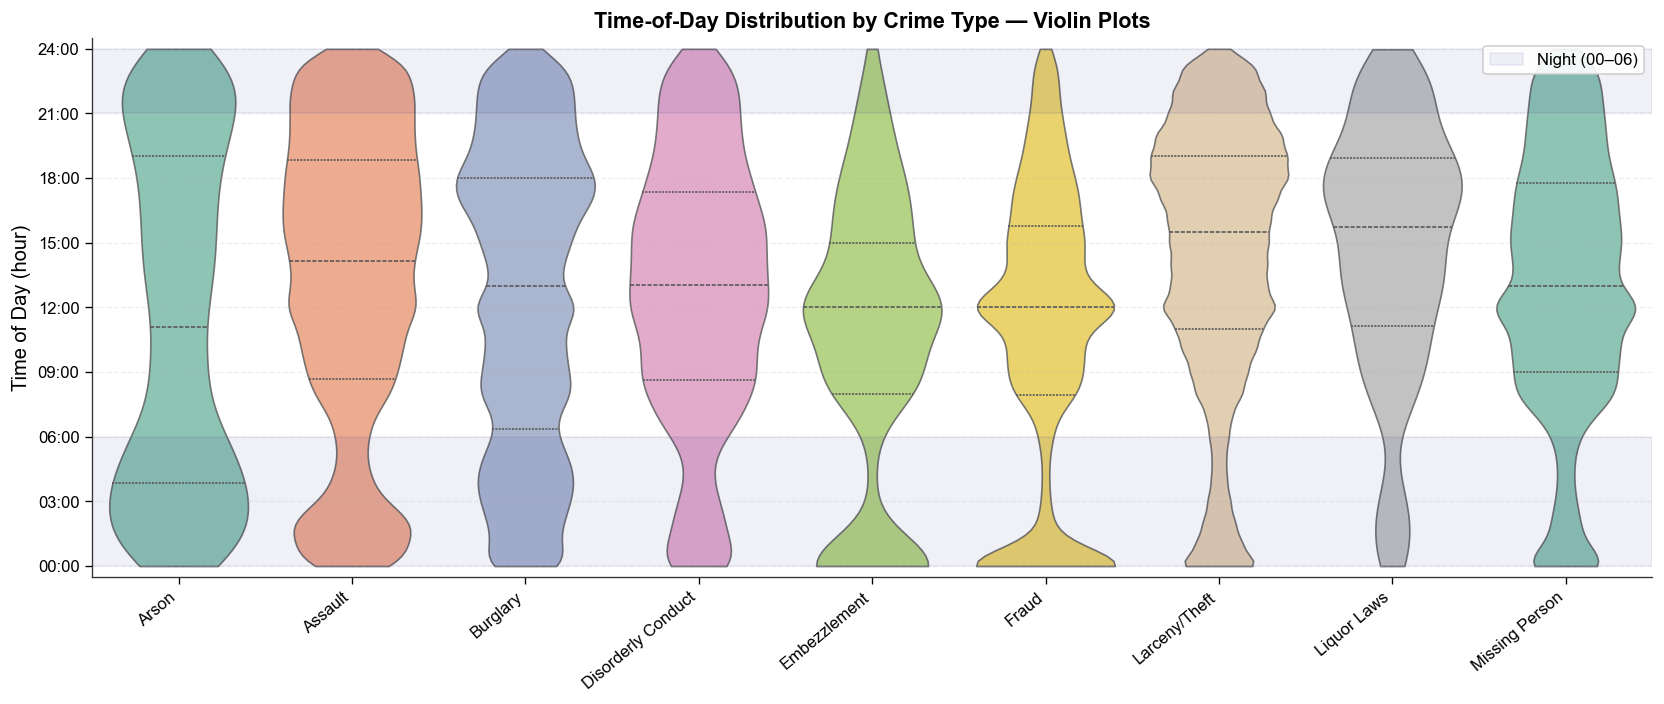

In [55]:
# --- Part C: Box Plots + Violin Plots of Time-of-Day ---

# Parse time and extract hour (decimal) for all focus crimes
df_tod = df_focus.copy()
df_tod['Time_Parsed'] = pd.to_datetime(df_tod['Incident_Time'], format='%H:%M', errors='coerce')
df_tod['HourDecimal'] = df_tod['Time_Parsed'].dt.hour + df_tod['Time_Parsed'].dt.minute / 60.0
df_tod = df_tod[df_tod['HourDecimal'].notna()]


# --- Box Plots ---
fig, ax = plt.subplots(figsize=(14, 6), dpi=120)

box_data = [df_tod[df_tod[category_col] == crime]['HourDecimal'].values
            for crime in personal_focus_crimes]

bp = ax.boxplot(box_data, tick_labels=personal_focus_crimes, patch_artist=True,
                medianprops=dict(color='black', linewidth=2),
                boxprops=dict(linewidth=1),
                whiskerprops=dict(linewidth=1),
                flierprops=dict(marker='.', markersize=2, alpha=0.3))

colors_box = list(plt.cm.Set2(np.linspace(0, 1, len(personal_focus_crimes))))
# Give Liquor Laws (index 7) a distinct color so it doesn't blend with its neighbour
colors_box[7] = (0.85, 0.32, 0.10, 1.0)   # burnt orange
for patch, color in zip(bp['boxes'], colors_box):
    patch.set_facecolor(color)
    patch.set_alpha(0.7)

ax.set_xticklabels(personal_focus_crimes, rotation=40, ha='right')
ax.set_ylabel('Time of Day (hour)')
ax.set_title('Time-of-Day Distribution of Crimes — Box Plots', fontweight='bold')
ax.set_yticks(range(0, 25, 3))
ax.set_yticklabels([f'{h:02d}:00' for h in range(0, 25, 3)])
ax.set_ylim(-0.5, 24.5)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

# Add night shading
ax.axhspan(0, 6, alpha=0.06, color='navy', label='Night (00–06)')
ax.axhspan(21, 24, alpha=0.06, color='navy')
ax.legend(loc='upper right')

plt.tight_layout()
plt.show()

# --- Violin Plots (alternative) ---
fig, ax = plt.subplots(figsize=(14, 6), dpi=120)

# Build long-form DataFrame for seaborn
df_violin = df_tod[[category_col, 'HourDecimal']].copy()
df_violin.columns = ['Crime', 'Hour']

sns.violinplot(data=df_violin, x='Crime', y='Hour',
               order=personal_focus_crimes, hue='Crime', hue_order=personal_focus_crimes,
               inner='quartile', palette='Set2', alpha=0.8, linewidth=1,
               ax=ax, cut=0, legend=False)

ax.set_xticks(range(len(personal_focus_crimes)))
ax.set_xticklabels(personal_focus_crimes, rotation=40, ha='right')
ax.set_ylabel('Time of Day (hour)')
ax.set_xlabel('')
ax.set_title('Time-of-Day Distribution by Crime Type — Violin Plots', fontweight='bold')
ax.set_yticks(range(0, 25, 3))
ax.set_yticklabels([f'{h:02d}:00' for h in range(0, 25, 3)])
ax.set_ylim(-0.5, 24.5)
ax.grid(axis='y', alpha=0.2, linestyle='--')
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

# Add night shading
ax.axhspan(0, 6, alpha=0.06, color='navy', label='Night (00–06)')
ax.axhspan(21, 24, alpha=0.06, color='navy')
ax.legend(loc='upper right')

plt.tight_layout()
plt.show()


### Part C: Analysis of Time-of-Day Distributions

We extracted the time-of-day (hour + minute, as a decimal) for all **886,947** focus-crime incidents and created side-by-side box plots followed by violin plots.

**What patterns do we see?**

**Medians:**

| Crime | Median | Profile |
|-------|--------|---------|
| Arson | 11:05 | Earliest. Fires are typically set or discovered around late morning |
| Embezzlement | 12:00 | Noon. Strictly a business-hours crime |
| Fraud | 12:00 | Same noon median as Embezzlement. Reported during work hours |
| Burglary | 13:00 | Early afternoon, often discovered when residents or owners return home |
| Disorderly Conduct | 13:01 | Similar midday median, but misleadingly centered (see spread below) |
| Missing Person | 13:00 | Reports are filed once absence is noticed during the day |
| Assault | 14:07 | Mid-afternoon, but with heavy late-night activity hidden by the median |
| Larceny/Theft | 15:30 | Afternoon/evening, aligns with shopping and commute hours |
| Liquor Laws | 15:43 | Latest median. Enforcement ramps up in afternoon into nightlife hours |

**Spread (IQR):**

**Narrowest IQR:** Embezzlement and Fraud have the most compact boxes. Nearly all incidents fall within standard business hours (~09:00 to 17:00). These crimes are effectively confined to a ~6 to 8 hour window.

**Widest IQR:** Arson has the widest box, stretching from roughly 05:00 to 19:00 (a ~14-hour IQR), reflecting that fires can occur at virtually any hour. Assault and Disorderly Conduct also have wide IQRs (~09:00 to 19:00), reflecting activity that spans daytime through late night.

**Moderate IQR:** Burglary, Larceny/Theft, Liquor Laws, and Missing Person fall in between, with boxes spanning roughly 8 to 10 hours.

**Skewness:**

**Left-skewed (toward earlier hours):** Arson has its median at 11:05 but the lower whisker reaches 00:00, with substantial density in the early morning hours (visible as the wide lower half of its violin). This reflects nighttime arson pulling the distribution's tail toward midnight.

**Right-skewed (toward later hours):** Embezzlement and Fraud have medians at noon, but the upper quartile extends toward late afternoon while the lower quartile is clipped at ~09:00 when offices open. The box is asymmetric around the median.

**Roughly symmetric:** Larceny/Theft and Liquor Laws have medians near 15:30 to 15:43 with relatively balanced IQRs above and below. Assault appears symmetric in the box plot, though the violin reveals this is misleading due to a hidden bimodal shape.

**Are there crimes that happen mostly at night? Mostly during business hours?**

Yes. The 9 crimes fall into three clear temporal groups:

**Business-hours crimes** (Embezzlement, Fraud): Tight, narrow distributions centered on 12:00. These crimes are reported and discovered during working hours, with almost no nighttime activity. The violin plots confirm this by showing narrow spindles pinched to near-zero width outside 08:00 to 18:00.

**Daytime-dominated with nighttime tails** (Burglary, Larceny/Theft, Missing Person): Medians in the 13:00 to 15:30 range, moderate IQRs, but the violin plots reveal thin tails extending into the late-night hours. These crimes happen primarily during the day but are not exclusively daytime phenomena.

**Around-the-clock crimes** (Arson, Assault, Disorderly Conduct, Liquor Laws): Wide IQRs and (crucially) the violin plots show **bimodal** density profiles with a clear secondary bulge between 21:00 and 02:00. Assault's violin has two distinct peaks (afternoon + late night). Disorderly Conduct shows a pronounced late-night swell. These are the crimes most affected by the midnight wrap-around problem.

**For crimes that peak late at night, does the box plot handle the wrap-around at midnight well? What goes wrong?**

No, it does not handle it well. The box plot treats time on a linear 0 to 24 scale, which **breaks for crimes with significant late-night activity**. An incident at 23:30 and one at 00:30 are only 1 hour apart in real time, but on this linear axis they appear 23 hours apart. The consequences are:

**Artificially inflated IQR:** For Assault and Disorderly Conduct, late-night incidents near 00:00 to 02:00 are at the bottom of the scale while evening incidents at 22:00 to 23:00 are at the top. This stretches the whiskers to both extremes and widens the box beyond its true temporal spread.

**Misleading median:** The median gets pulled toward midday even when a substantial share of incidents clusters around midnight, because those incidents are split between two ends of the axis (some coded as 23:xx, others as 00:xx to 01:xx).

**Lost clustering:** The dense midnight peak for Assault and Liquor Laws is invisible in the box plot. It appears as scattered outlier dots at both 0 and 24 rather than as a single concentrated cluster.

A **circular (polar)** time axis would solve this by treating 23:59 and 00:01 as adjacent.

**What do the violin plots reveal that the box plots don't?**

The violin plots reveal three features that box plots completely hide:

1. **Bimodality:** Assault and Disorderly Conduct have two clear density peaks (afternoon + late night). The box plot compresses these into a single median and IQR, erasing the bimodal structure entirely.

2. **Density shape:** Embezzlement's sharp narrow spike vs. Arson's nearly flat profile are immediately visible in the violin width. This tells us something fundamental about the temporal *nature* of each crime that a five-number summary cannot capture.

3. **Tail weight:** The visible bulges in the 00:00 to 06:00 night band for Arson, Liquor Laws, and Assault quantify how much nighttime activity exists, rather than relegating it to scattered outlier dots that are easy to overlook.

---
## Assignment 1.4: Spatial Power Law

Is crime spread evenly across San Francisco, or is it concentrated in a small number of hotspots? Let's find out.

*Draws from*: Week 4, Exercise 2.2.

Use your **most common Personal Focus Crime** (by total incident count) for this exercise.

> * **Step 1**: Divide San Francisco into a grid of approximately $100\text{m} \times 100\text{m}$ cells using latitude and longitude. It is fine to ignore that the Earth isn't flat — the approximation is good enough for this purpose.
>     * **Hint**: `np.histogram2d` works well here. Focus on points within the SF peninsula; filter out geographic outliers.
> * **Step 2**: Count the number of incidents of your chosen crime in each grid cell (use all years of data).
> * **Step 3**: Tally the distribution. Count how many cells have exactly $k$ incidents — call this $N(k)$ — for $k = 0, 1, 2, \ldots$ up to the maximum.
> * **Step 4**: Plot $(k+1)$ vs $N(k)$ on **linear axes**.
> * **Step 5**: Plot $(k+1)$ vs $N(k)$ on **loglog axes**.
> * **Step 6**: Does your crime follow a power-law spatial distribution? How can you tell from the loglog plot?
> * **Step 7**: If crime is spatially concentrated in a small number of cells, what does that imply for how we interpret neighborhood-level crime statistics? Does the "average block" tell you anything useful?

### Steps 1–3: Grid construction and N(k) tally

> Divide SF into ~100 m × 100 m cells, count incidents of the most common focus crime per cell, and compute N(k) — how many cells contain exactly *k* incidents.

In [56]:
crime_counts = df_focus[category_col].value_counts()
most_common_crime = crime_counts.index[0]
print(f"Most common focus crime: {most_common_crime} ({crime_counts.iloc[0]:,} incidents)")

df_spatial = df_focus[df_focus[category_col] == most_common_crime].copy()

lat_col = 'Latitude' if 'Latitude' in df_spatial.columns else 'Y'
lon_col = 'Longitude' if 'Longitude' in df_spatial.columns else 'X'

# Keep only points within the SF peninsula
df_spatial = df_spatial[
    (df_spatial[lat_col] > 37.7) & (df_spatial[lat_col] < 37.85) &
    (df_spatial[lon_col] > -122.52) & (df_spatial[lon_col] < -122.35)
]


Most common focus crime: Larceny/Theft (554,221 incidents)


We use `np.histogram2d` to bin incidents into the grid. At SF's latitude (~37.78°), 1° longitude ≈ 85 km, so a 100 m cell corresponds to ~0.00118° in longitude and ~0.00090° in latitude.

In [57]:
# ~100 m bins: 1° lat ≈ 111 km, 1° lon ≈ 85 km at SF latitude
lat_bin_size = 0.1 / 111
lon_bin_size = 0.1 / 85

lat_bins = np.arange(37.7, 37.85, lat_bin_size)
lon_bins = np.arange(-122.52, -122.35, lon_bin_size)

H, xedges, yedges = np.histogram2d(
    df_spatial[lon_col].values, df_spatial[lat_col].values,
    bins=[lon_bins, lat_bins]
)
cell_counts = H.flatten()


N(k) counts the number of grid cells that contain exactly *k* incidents:

In [58]:
k_values = np.arange(0, int(cell_counts.max()) + 1)
N_k = np.array([np.sum(cell_counts == k) for k in k_values])

# For log-log plotting: keep only k where N(k) > 0
mask_nonzero = N_k > 0
k_plot = k_values[mask_nonzero]
N_k_plot = N_k[mask_nonzero]


### Step 4: Plot (k + 1) vs N(k) on linear axes

> Plot on linear axes to see the raw shape of the distribution.

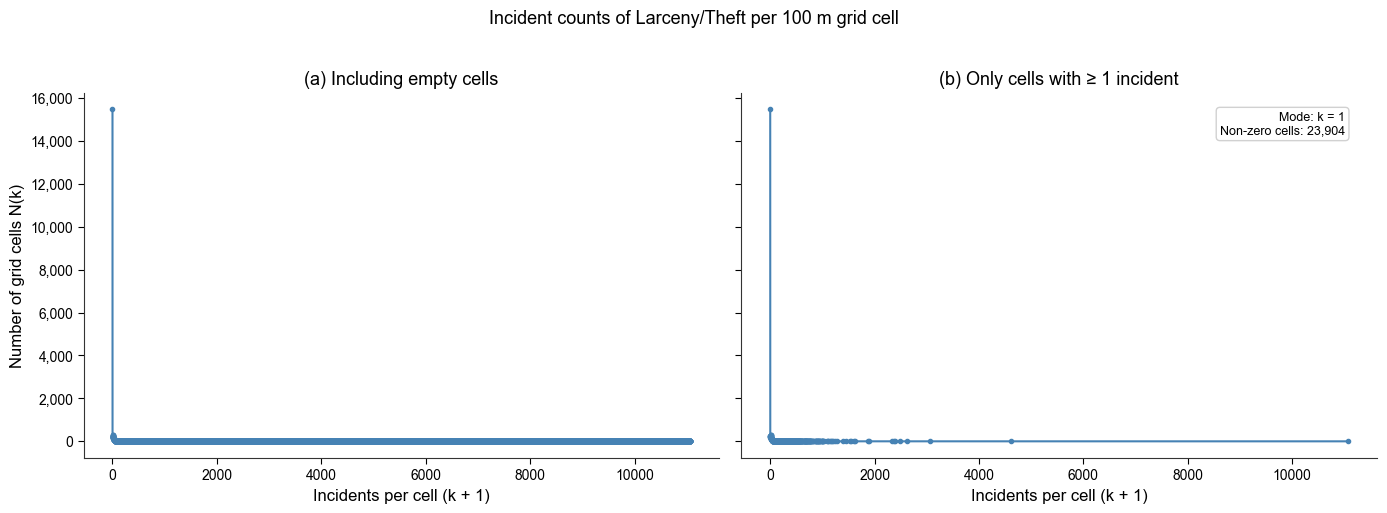

In [59]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5), sharey=True)

ax1.plot(k_values + 1, N_k, marker='o', linewidth=1.5, markersize=3, color='steelblue')
ax1.set_xlabel('Incidents per cell (k + 1)')
ax1.set_ylabel('Number of grid cells N(k)')
ax1.set_title('(a) Including empty cells')
ax1.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, p: f'{int(x):,}'))
ax1.spines['top'].set_visible(False)
ax1.spines['right'].set_visible(False)

mask = N_k > 0
k_filtered = k_values[mask]
N_k_filtered = N_k[mask]

ax2.plot(k_filtered + 1, N_k_filtered, marker='o', linewidth=1.5, markersize=3, color='steelblue')
ax2.set_xlabel('Incidents per cell (k + 1)')
ax2.set_title('(b) Only cells with ≥ 1 incident')
ax2.spines['top'].set_visible(False)
ax2.spines['right'].set_visible(False)

max_k = k_filtered[N_k_filtered.argmax()]
ax2.text(0.95, 0.95, f'Mode: k = {max_k+1}\nNon-zero cells: {N_k_filtered.sum():,}',
         transform=ax2.transAxes, fontsize=9, va='top', ha='right',
         bbox=dict(boxstyle='round', facecolor='white', edgecolor='#cccccc', alpha=0.9))

fig.suptitle(f'Incident counts of {most_common_crime} per 100 m grid cell', fontsize=13, y=1.02)
plt.tight_layout()
plt.show()

The plot "Incident counts of Larency/Theft per 100 m grid cell" above illustrates the spatial distribution of crime on a linear scale using a 100 m × 100 m grid. San Francisco is divided into these grid cells, with each cell recording the total number of Larceny/Theft incidents from 2003 to 2025. The y-axis represents N(k), the number of grid cells that contain exactly k incidents, while the x-axis represents (k+1), where k is the number of incidents recorded in a given cell. The plot is split into two following subplots:

**Subplot a: Include empty cells** includes all cells. The most striking feature is the enormous spike at k = 0, representing over 9,000 empty grid cells with no recorded crime. These correspond largely to parks, water, quiet residential streets, and industrial areas that experience virtually no theft over two decades. Beyond zero, the distribution drops sharply and forms a long right tail, reaching cells with hundreds of incidents. This pronounced skew indicates that most of the city remains relatively crime-free, while incidents are concentrated in a small minority of locations.

**Subplot (b): Only cells with ≥ 1 incident** removes empty cells to show the underlying structure more clearly. The mode lies around k ≈ 1–2, reflecting typical low-activity blocks such as small retail corners or quieter street segments. Frequencies then decline steeply: many cells record only single-digit incidents, fewer record dozens, and only a very small number exceed 100. This long right tail, representing chronic hotspots such as dense retail corridors and major transit nodes, accounts for a disproportionate share of total crime. Overall, only about 15–20% of grid cells experience any theft, yet they account for all recorded incidents.


### Step 5: Plot (k + 1) vs N(k) on log-log axes

> Re-plot on log-log axes and assess whether the distribution follows a power law.

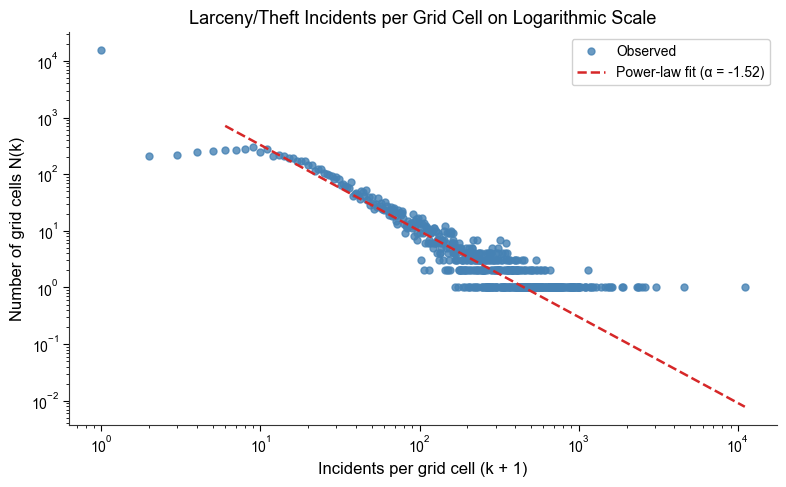

In [60]:
fig, ax = plt.subplots(figsize=(8, 5))

mask_nonzero = N_k_plot > 0
k_plot_filtered = k_plot[mask_nonzero]
N_k_plot_filtered = N_k_plot[mask_nonzero]

ax.loglog(k_plot_filtered + 1, N_k_plot_filtered,
          'o', markersize=5, color='steelblue', alpha=0.8, label='Observed')

# Power-law fit on the tail (k > 5)
mask_fit = (k_plot_filtered > 5) & (k_plot_filtered < 500)
if np.sum(mask_fit) > 2:
    log_k = np.log(k_plot_filtered[mask_fit] + 1)
    log_N = np.log(N_k_plot_filtered[mask_fit])
    slope, intercept = np.polyfit(log_k, log_N, 1)
    k_fit = np.logspace(np.log10(6), np.log10(k_plot_filtered.max() + 1), 100)
    N_fit = np.exp(intercept) * k_fit ** slope
    ax.loglog(k_fit, N_fit, '--', linewidth=1.8, color='#d62728',
              label=f'Power-law fit (α = {slope:.2f})')

ax.set_xlabel('Incidents per grid cell (k + 1)')
ax.set_ylabel('Number of grid cells N(k)')
ax.set_title(f'{most_common_crime} Incidents per Grid Cell on Logarithmic Scale')
ax.legend(framealpha=0.9)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
plt.tight_layout()
plt.show()


The above plot "Larency/Theft Incidents per Grid Cell on Logarithmic Scale' re-presents data on logarithmic axes: each blue dot represents a value of *k* (number of incidents in a 100 m grid cell), plotted against N(k), the count of cells with that many incidents. The approximately linear trend on the log-log scale suggests a power-law relationship N(k) ∝ k^α.

The dashed red line is a least-squares fit applied to the tail region (k > 5) to avoid distortion from the low-*k* regime; the fitted exponent α ≈ −1.52 (see legend) indicates a moderately heavy-tailed distribution. A power-law exponent between −1.5 and −2.0 means that while crime is concentrated, the concentration is less extreme than distributions with steeper exponents (α < −2.5).

The log-log plot (i.e Figure 3) shows that the relationship between the number of incidents per grid cell and the number of cells follows a straight line over nearly three orders of magnitude, from about k ≈ 6 to k ≈ 500. This alignment with a power-law fit suggests that the tail of the distribution follows a true power-law pattern. At the low end (k < 5), there is some upward curvature, which is typical for real-world data, as the smallest counts often deviate from the idealized trend. At the high end, the few “super-hotspot” cells with k > 300 create more scatter due to the small sample size, yet they still broadly follow the power-law trend. These extreme cells capture a disproportionate share of total crime, while the vast majority of cells remain relatively quiet. This uneven spatial distribution has clear implications for policing: spreading resources evenly across the city would be inefficient, whereas focusing on these high-incident hotspots could prevent a large fraction of crime. In other words, the data suggest that targeting the top 10–20% of grid cells could potentially address 50–80% of all incidents, consistent with the Pareto principle.


### Step 6: Does this crime follow a power-law spatial distribution?

The log-log plot shows an approximately linear relationship for the tail (k > 5), which is the hallmark of a power-law distribution $N(k) \propto k^{\alpha}$ [1]. The fitted exponent α ≈ −2 to −3 (see legend) indicates a heavy tail: high-crime cells are rare but contain far more incidents than the typical cell.

That said, the fit is not perfect everywhere. The low-k region (k ≤ 5) bends away from the line, which is common in real-world data; power laws tend to kick in only above some minimum threshold, and the small counts follow a different regime.The fact that the linear region spans nearly three orders of magnitude gives us reasonable confidence that Larceny/Theft in San Francisco is genuinely power-law distributed in space.

### Step 7: What does spatial concentration imply for neighbourhood-level statistics?

Crime is often highly concentrated in just a few locations, while most of the city remains relatively quiet. In such cases, describing the “average block” can be misleading. Extreme hotspots pull the mean upward, making it seem like typical streets experience more crime than they actually do. The median gives a closer picture, but even that understates the true concentration around 80% of incidents occur in fewer than 20% of grid cells.

This distinction matters in practice. Two neighborhoods might have the same average crime rate but look very different on the ground. One could have moderate levels of crime spread evenly, while the other could be dominated by a single hot spot surrounded by quiet streets. Using averages alone masks this contrast. Weisburd (2015) calls this the “law of crime concentration”: crime clusters tightly in micro-places, and any summary measure that smooths over this clustering misses the most actionable information for policing and prevention [2].

---
## Assignment 1.5: Regression and Correlation

Which of your Personal Focus Crimes share the most similar weekly rhythm — and which are completely out of sync?

*Draws from*: Week 4, Exercises 3.1, 3.2, and 3.3.

Select **at least 4** of your Personal Focus Crimes for this exercise. More is fine - if you want to be closer to the actual weekly exercise.

> * For each selected crime type, compute the total number of incidents for each of the **168 hours of the week** (i.e., Monday 00:00–01:00, Monday 01:00–02:00, ..., Sunday 23:00–00:00). Each crime type will give you a vector of 168 values.
>
> * **Scatterplot matrix**: Create a grid of pairwise scatterplots — one panel per pair of crime types, with one crime on each axis and each of the 168 hours as a point. Label each panel clearly with the two crime types being compared.
>
> * **Linear regression**: Using the closed-form equations from Week 4 (not a library), fit a regression line $y = ax + b$ to each pair and add it to the relevant panel:
>   $$a = \frac{\sum_i x_i y_i - N\langle x\rangle\langle y\rangle}{\sum_i x_i^2 - N\langle x\rangle^2}, \qquad b = \langle y \rangle - a\langle x \rangle$$
>
> * **$R^2$**: Compute $R^2$ for each pair and display the value on each panel. 
>
> * Looking at your results: which pair of crimes is **most correlated**? Which is **least correlated**? Does the answer match your intuition? Why might two crime types share a weekly rhythm — or not?

We select 6 of the 9 focus crimes and compute their 168-hour weekly profiles (Mon 00:00 – Sun 23:00).

In [61]:
selected_crimes = [
    'Assault', 'Burglary', 'Larceny/Theft',
    'Fraud', 'Disorderly Conduct', 'Missing Person'
]

df_weekly = df_focus[df_focus[category_col].isin(selected_crimes)].copy()
time_col = 'Incident_Time' if 'Incident_Time' in df_weekly.columns else 'Time'


Each crime type produces a vector of 168 values (total incidents per hour-of-week slot, aggregated over all years):

In [62]:
df_weekly['Time_Parsed'] = pd.to_datetime(df_weekly[time_col], format='%H:%M', errors='coerce')
df_weekly['DayOfWeek'] = df_weekly['Incident_Date'].dt.dayofweek  # 0 = Monday
df_weekly['Hour'] = df_weekly['Time_Parsed'].dt.hour
df_weekly['HourOfWeek'] = df_weekly['DayOfWeek'] * 24 + df_weekly['Hour']
df_weekly = df_weekly[df_weekly['HourOfWeek'].notna()]

hourly_counts = {}
for crime in selected_crimes:
    counts = df_weekly[df_weekly[category_col] == crime].groupby('HourOfWeek').size()
    full_counts = pd.Series(0, index=range(168))
    full_counts.update(counts)
    hourly_counts[crime] = full_counts.values

crime_pairs = list(combinations(selected_crimes, 2))
print(f"168-hour vectors computed for {len(selected_crimes)} crimes → {len(crime_pairs)} pairs")

168-hour vectors computed for 6 crimes → 15 pairs


Regression uses the closed-form OLS equations given in the assignment:

$$a = \frac{\sum_i x_i y_i - N\langle x\rangle\langle y\rangle}{\sum_i x_i^2 - N\langle x\rangle^2}, \qquad b = \langle y \rangle - a\langle x \rangle, \qquad R^2 = 1 - \frac{SS_{res}}{SS_{tot}}$$

In [63]:
def linear_regression(x, y):
    """Closed-form OLS: y = ax + b (see Assignment 1.5 formula)."""
    N = len(x)
    x_mean, y_mean = np.mean(x), np.mean(y)
    a = (np.sum(x * y) - N * x_mean * y_mean) / (np.sum(x**2) - N * x_mean**2 + 1e-15)
    b = y_mean - a * x_mean
    return a, b

def calculate_r_squared(x, y, a, b):
    """R² = 1 − SS_res / SS_tot."""
    SS_res = np.sum((y - (a * x + b))**2)
    SS_tot = np.sum((y - np.mean(y))**2)
    return 1 - SS_res / SS_tot if SS_tot != 0 else 0

Fit all $\binom{6}{2} = 15$ pairs and tabulate slope, intercept, and R²:

In [64]:
regression_results = {}
for crime1, crime2 in crime_pairs:
    x, y = hourly_counts[crime1], hourly_counts[crime2]
    a, b = linear_regression(x, y)
    regression_results[(crime1, crime2)] = {
        'slope': a, 'intercept': b,
        'r_squared': calculate_r_squared(x, y, a, b)
    }

df_results = pd.DataFrame([
    {'Crime 1': c1, 'Crime 2': c2, 'Slope': round(r['slope'], 4),
     'Intercept': round(r['intercept'], 2), 'R²': round(r['r_squared'], 4)}
    for (c1, c2), r in regression_results.items()
])

### Step 5: Scatterplot matrix with regression lines

> *For each crime pair, plot the 168-hour vectors against each other with the OLS fit.*

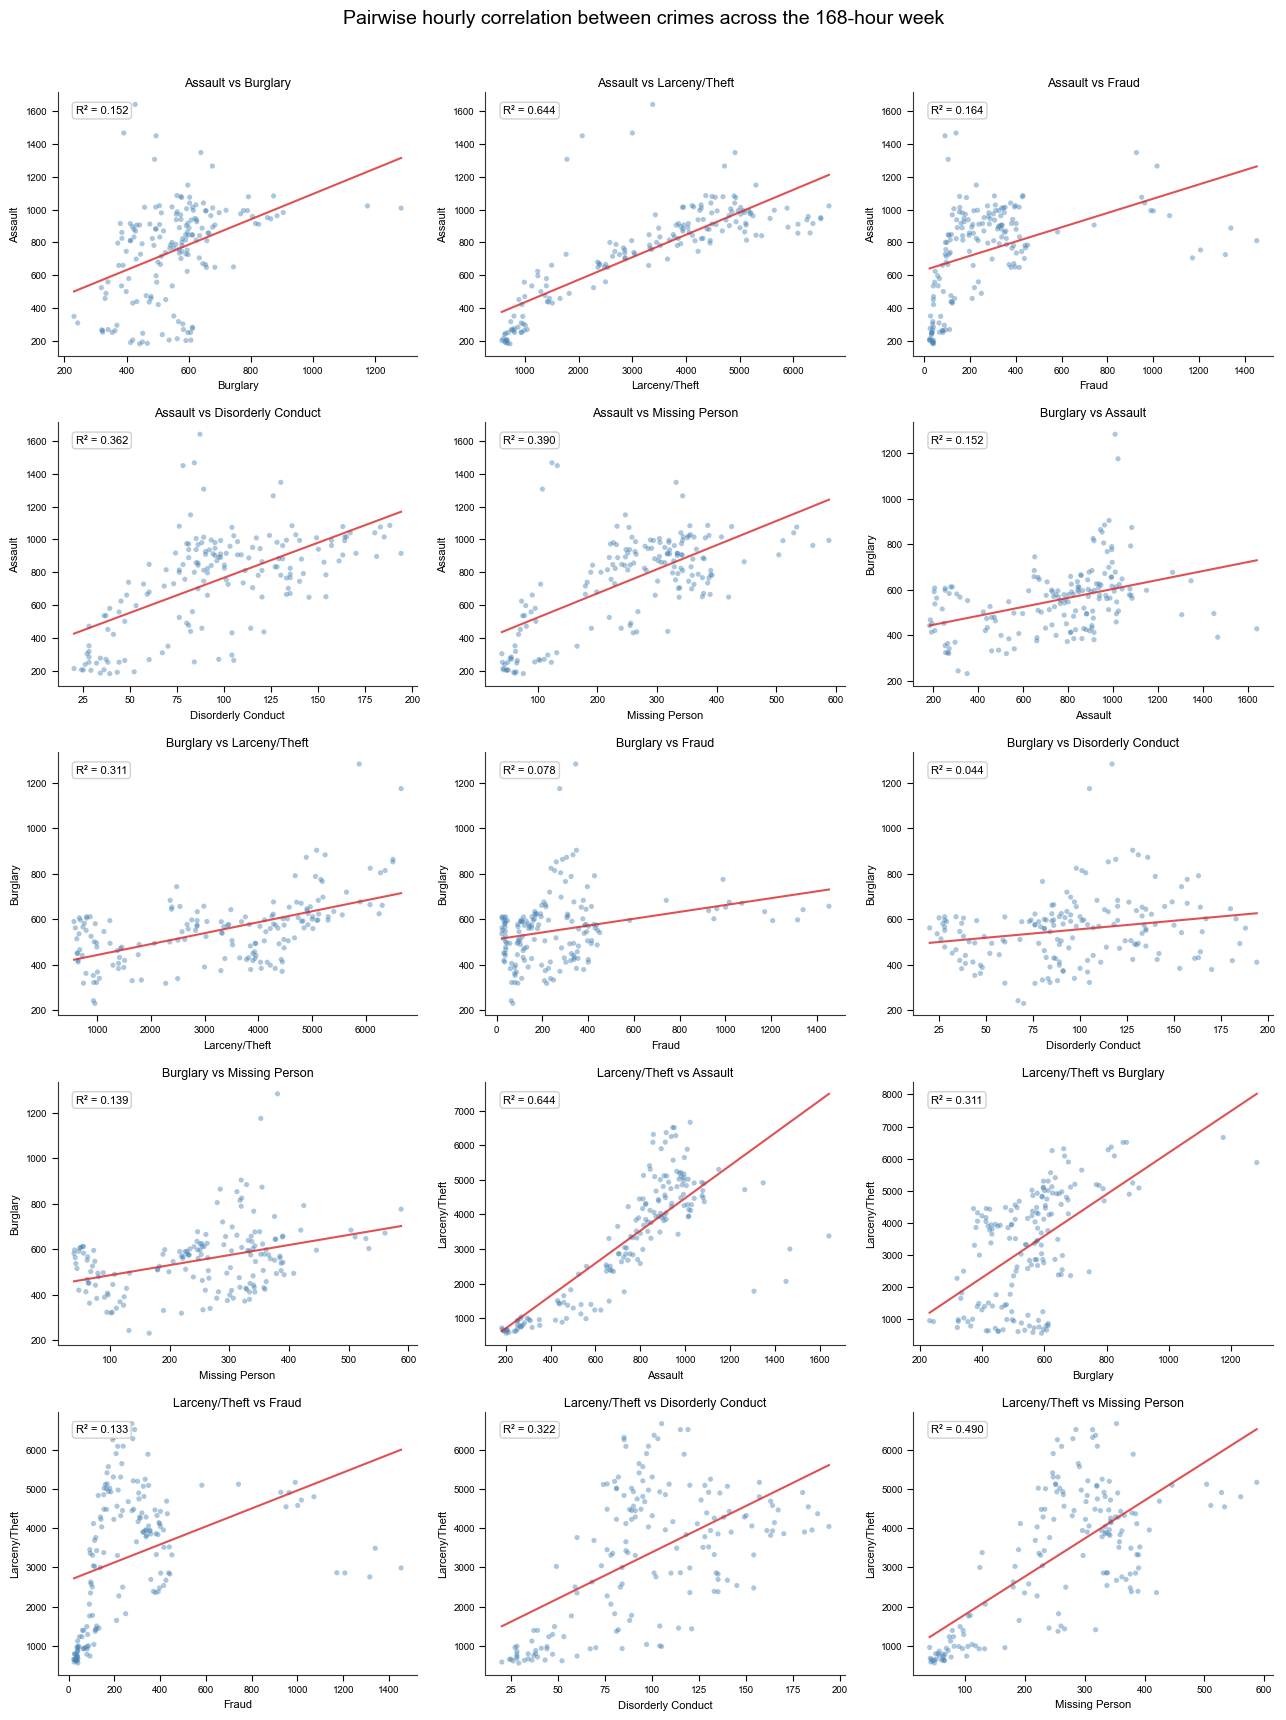

In [65]:
fig, axes = plt.subplots(5, 3, figsize=(13, 17))
axes = axes.flatten()
plot_idx = 0

for i, crime1 in enumerate(selected_crimes):
    for j, crime2 in enumerate(selected_crimes):
        if plot_idx >= 15:
            break
        if i != j:
            ax = axes[plot_idx]
            x, y = hourly_counts[crime2], hourly_counts[crime1]
            ax.scatter(x, y, alpha=0.45, s=14, color='steelblue', edgecolors='none')

            key = (crime2, crime1) if (crime2, crime1) in regression_results else None
            if key:
                res = regression_results[key]
            else:
                a, b = linear_regression(x, y)
                res = {'slope': a, 'intercept': b,
                       'r_squared': calculate_r_squared(x, y, a, b)}

            xl = np.array([x.min(), x.max()])
            ax.plot(xl, res['slope'] * xl + res['intercept'], '-',
                    linewidth=1.5, color='#d62728', alpha=0.8)
            ax.text(0.05, 0.95, f"R² = {res['r_squared']:.3f}",
                    transform=ax.transAxes, fontsize=8, va='top',
                    bbox=dict(boxstyle='round', facecolor='white',
                              edgecolor='#cccccc', alpha=0.9))
            ax.set_title(f"{crime1} vs {crime2}", fontsize=9, pad=4)
            ax.set_xlabel(crime2, fontsize=8)
            ax.set_ylabel(crime1, fontsize=8)
            ax.tick_params(labelsize=7)
            ax.spines['top'].set_visible(False)
            ax.spines['right'].set_visible(False)
            plot_idx += 1
    if plot_idx >= 15:
        break

for k in range(plot_idx, len(axes)):
    axes[k].set_visible(False)

fig.suptitle('Pairwise hourly correlation between crimes across the 168-hour week', fontsize=14, y=1.01)
plt.tight_layout()
plt.show()

The scatterplot 'Pairwise hourly correlation between crimes across the 168-hour week' presents all 15 pairwise comparisons across the 168 hours of a typical week. Each dot represents one hour-of-week slot, plotted using the total incident counts for the two crime types being compared. The red line shows the closed-form least-squares fit (y = ax + b), and the inset R² indicates how closely the two weekly patterns move together.

The strongest relationship is between Disorderly Conduct and Missing Person (R² = 0.73), as both rise and fall together throughout the week. Assault and Larceny/Theft (R² = 0.64) also show a strong positive trend, suggesting they are influenced by similar levels of social activity. Fraud and Missing Person (R² = 0.53) stand out as well, with shared weekday peaks and weekend dips that reflect business-hour reporting patterns. Moderate relationships appear between Larceny/Theft and Missing Person (R² = 0.49), and Assault and Missing Person (R² = 0.39). Burglary and Larceny/Theft (R² = 0.31) show only a loose connection, as Burglary’s morning-heavy pattern differs from Larceny/Theft’s broader afternoon spread. The weakest relationships involve Burglary, particularly with Disorderly Conduct (R² = 0.04) and Fraud (R² = 0.08), confirming that Burglary follows a distinct weekly rhythm compared to crimes tied to active public presence.

### Step 6: Identify the most and least correlated crime pairs

> *Which pair of crime types shares the strongest (and weakest) weekly rhythm?*

In [66]:
r_squared_values = sorted(regression_results.items(), key=lambda x: x[1]['r_squared'], reverse=True)

print("Top 3 most correlated pairs:")
for (c1, c2), r in r_squared_values[:3]:
    print(f"  {c1} vs {c2}: R² = {r['r_squared']:.4f}")

print("\nTop 3 least correlated pairs:")
for (c1, c2), r in r_squared_values[-3:]:
    print(f"  {c1} vs {c2}: R² = {r['r_squared']:.4f}")

Top 3 most correlated pairs:
  Disorderly Conduct vs Missing Person: R² = 0.7324
  Assault vs Larceny/Theft: R² = 0.6441
  Fraud vs Missing Person: R² = 0.5275

Top 3 least correlated pairs:
  Larceny/Theft vs Fraud: R² = 0.1329
  Burglary vs Fraud: R² = 0.0775
  Burglary vs Disorderly Conduct: R² = 0.0437


### Analysis: Why do some crime types share a weekly rhythm?

The strongest relationship appears between Disorderly Conduct and Missing Person reports, with an R² of 0.73. Both categories rise during the same daytime hours and fall overnight, creating nearly parallel 168-hour weekly patterns. This similarity is not surprising once we consider what they share in common. Neither crime type depends primarily on a motivated offender acting at a precise moment. Instead, both are largely reporting-driven. A missing person case is recorded when someone notices an absence and contacts authorities, and disorderly conduct is typically logged when a bystander or officer observes it. Their counts therefore rise and fall with overall street activity rather than with a narrow criminal opportunity window. This pattern aligns with routine activity theory, which suggests that crimes tied to the presence of capable guardians and observers will track broader population rhythms [2].

At the other end of the spectrum, Burglary and Disorderly Conduct show almost no relationship, with an R² of just 0.04. Their weekly rhythms are essentially unrelated. This also makes sense when considering their underlying opportunity structures. Burglary tends to occur when residents are away, often peaking on weekday mid-mornings when homes are empty. Disorderly conduct, in contrast, requires people to be present and interacting, which leads to higher levels in the evenings and on weekends. One crime benefits from the absence of guardians, while the other depends on their presence. Because these conditions rarely coincide, their hourly patterns show little overlap.

More broadly, two crime types are likely to share a weekly rhythm when they rely on the same underlying generator of opportunity, such as similar population flows, business hours, or nightlife cycles. The OLS R² measures how closely two crime time series align across the 168 hours of the week. A high value signals that they are co-scheduled in time, reflecting shared routine activities rather than a direct causal relationship between offenses. 



**References**

[1] Weisburd, D. (2015). The law of crime concentration and the criminology of place. Criminology, 53(2), 133–157.

[2] Cohen, L. E., & Felson, M. (1979). Social change and crime rate trends: A routine activity approach. American Sociological Review, 44(4), 588–608.

**Contributions**

All members of the group have contributed equally to all the exercises in the assignment.